In [ ]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import mne
from scipy.optimize import minimize
from scipy.stats import norm, skewnorm


repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [34]:
task = 'Active'
file_path = f'Fit_{task}_late_19blocks'
os.makedirs(file_path, exist_ok=True)

models_dict, distributions_dict, binarized_audibilities_dict = {}, {}, {}
    
for part in tqdm(range(20)):

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # sort audibilities according to SNR
    sorted_audibilities = {cat: [] for cat in categories}
    binarized_audibilities = {cat: [] for cat in categories}
    for cat in categories:
        cat_indices = np.where(snr == (cat + 1))[0]
        sorted_audibilities[cat] = audibility[cat_indices]
        binarized_audibilities[cat] = (sorted_audibilities[cat] >= 2).astype(int)
    binarized_audibilities_dict[part] = binarized_audibilities

    # format data into distributions (one per category)
    distributions = {cat: np.mean(state_train[cat][:, 90:100], axis=-1).flatten() for cat in categories}
    distributions_dict[part] = distributions

    # load model parameters 
    model = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path + f"/GainModulatedModel_part{part}_params"
    model.load_params(param_path)
    models_dict[part] = model

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_63644/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_63644/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_63644/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_63644/174317111.py:14: RuntimeWarning: The 

In [ ]:

for part in [18]: #range(20):

    model, distributions, binarized_audibilities = models_dict[part], distributions_dict[part], binarized_audibilities_dict[part]

    # Run simulations based on the model
    n_trials = 10000
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(100)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    measures = model.measure_simulations(input_series=input_series)
    measured_distributions = {cat: np.mean(measures[cat][:, 90:100], axis=-1).flatten() for cat in categories}

    # Pull fitted model parameters
    params = model.get_params()
    tau = float(params['tau'])
    sigma_q = float(params['process_noise'])
    sigma_r = float(params['measure_noise'])

    # Parameters for time-averaging
    n = 10 # number of time-points averaged
    dt = 1
    alpha_continuity_penalty_coef = 0

    # Fix lambda to 0 if you want two real Gaussians in the mixture
    fix_lambda_to_zero = False

    # Calculate shared resting-state spread (time-averaged)
    rho = np.exp(-dt / tau)
    ou_variance_avg = (tau * (sigma_q ** 2) / (2.0 * n)) * \
                    ((1.0 + rho) / (1.0 - rho) - (2.0 * rho * (1.0 - rho**n)) / (n * (1.0 - rho)**2))
    measure_variance_avg = (sigma_r ** 2) / n
    sigma_rest = np.sqrt(ou_variance_avg + measure_variance_avg)

    # Define categories
    categories = [0, 1, 2, 3, 4, 5]
    last_category = categories[-1]
    forced_zero_alpha_category = 0
    fixed_one_categories = [cat for cat in categories if cat <= forced_zero_alpha_category]
    fixed_zero_category = last_category
    fit_categories = [cat for cat in categories if cat not in fixed_one_categories and cat != fixed_zero_category]
    mu1_fit_categories = fit_categories + [fixed_zero_category]
    num_fit_cats = len(fit_categories)
    num_mu1_fit_cats = len(mu1_fit_categories)

    if forced_zero_alpha_category >= fixed_zero_category:
        raise ValueError("forced_zero_alpha_category must be smaller than the last category.")


    # --- 1. Precompute fixed parameters, bounds, and initial values ---

    mu_rest_dict = {}
    data_dict = {}
    bounds_alphas = []
    bounds_mu1s = []
    bounds_log_sigmas = []
    init_mu1s = []

    x0 = np.asarray(measured_distributions[0], dtype=float)
    x0 = x0[np.isfinite(x0)]
    mu_rest_dict[0] = float(params.get('w0', 0.0)) * tau
    data_dict[0] = x0

    for cat in fixed_one_categories[1:] + [fixed_zero_category]:
        mu_rest_dict[cat] = float(params.get(f'w{cat}', 0.0)) * tau

    for cat in fit_categories:
        x = np.asarray(measured_distributions[cat], dtype=float)
        x = x[np.isfinite(x)]
        data_dict[cat] = x
        mu_rest_dict[cat] = float(params.get(f'w{cat}', 0.0)) * tau

        if x.size > 0:
            x_mean = float(np.mean(x))
        else:
            x_mean = 0.0

        init_mu1s.append(x_mean)
        bounds_alphas.append((1e-4, 1.0 - 1e-4))
        bounds_mu1s.append((0, 3))
        bounds_log_sigmas.append((np.log(1e-4), np.log(10.0)))

    endpoint_mu1_init = float(np.mean(init_mu1s[-1:])) if init_mu1s else 0.0
    bounds_mu1s.append((0, 3))
    init_mu1s.append(endpoint_mu1_init)

    # One lambda per mu1_fit_category, increasing with category
    if fix_lambda_to_zero:
        bounds_lambdas = [(0.0, 0.0)] * num_mu1_fit_cats
    else:
        bounds_lambdas = [(-8.0, 0.0)] * num_mu1_fit_cats

    bounds = bounds_alphas + bounds_mu1s + bounds_log_sigmas + bounds_lambdas

    nonzero_init_alphas = np.linspace(0.9, 0.1, len(fit_categories)).tolist() if fit_categories else []
    init_alphas = []
    nonzero_alpha_idx = 0
    for cat in fit_categories:
        if cat <= forced_zero_alpha_category:
            init_alphas.append(1.0)
        elif cat == fixed_zero_category:
            init_alphas.append(0.0)
        else:
            init_alphas.append(nonzero_init_alphas[nonzero_alpha_idx])
            nonzero_alpha_idx += 1

    init_log_sigmas = [np.log(sigma_rest)] * num_fit_cats
    init_lambdas = [-1.0] * num_mu1_fit_cats

    init_theta = np.array(init_alphas + init_mu1s + init_log_sigmas + init_lambdas, dtype=float)

    lambda_offset = num_fit_cats + num_mu1_fit_cats + num_fit_cats


    # --- 2. Define the Joint Negative Log-Likelihood ---

    def joint_nll(theta):
        alphas     = theta[0:num_fit_cats]
        mu1s       = theta[num_fit_cats : num_fit_cats + num_mu1_fit_cats]
        log_sigmas = theta[num_fit_cats + num_mu1_fit_cats : num_fit_cats + num_mu1_fit_cats + num_fit_cats]
        lambdas    = theta[lambda_offset:]

        total_nll = 0.0

        mu0 = mu_rest_dict[0]
        if x0.size > 0:
            p0 = norm.pdf(x0, loc=mu0, scale=sigma_rest)
            total_nll -= np.sum(np.log(np.maximum(p0, 1e-300)))

        for i, cat in enumerate(fit_categories):
            x = data_dict[cat]
            if x.size == 0:
                continue

            mu0    = mu_rest_dict[cat]
            alpha  = alphas[i]
            mu1    = mu1s[i]
            sigma1 = np.exp(log_sigmas[i])
            lam    = lambdas[i]

            p0 = norm.pdf(x, loc=mu0, scale=sigma_rest)
            p1 = skewnorm.pdf(x, a=lam, loc=mu1, scale=sigma1)
            p  = alpha * p0 + (1.0 - alpha) * p1
            total_nll -= np.sum(np.log(np.maximum(p, 1e-300)))

        if fixed_zero_category in data_dict and num_mu1_fit_cats > num_fit_cats:
            x = data_dict[fixed_zero_category]
            if x.size > 0:
                mu1    = mu1s[-1]
                sigma1 = np.exp(log_sigmas[-1])
                lam    = lambdas[-1]
                p1 = skewnorm.pdf(x, a=lam, loc=mu1, scale=sigma1)
                total_nll -= np.sum(np.log(np.maximum(p1, 1e-300)))

        if num_fit_cats > 0 and alpha_continuity_penalty_coef != 0.0:
            alpha_full = np.empty(len(categories), dtype=float)
            alpha_full[fixed_one_categories] = 1.0
            alpha_full[fixed_zero_category] = 0.0
            for i, cat in enumerate(fit_categories):
                alpha_full[cat] = alphas[i]
            alpha_diffs = np.diff(alpha_full)
            total_nll += alpha_continuity_penalty_coef * np.sum(alpha_diffs ** 2) / len(alpha_diffs)

        return total_nll


    # --- 3. Define Constraints ---

    constraints = []

    # alpha decreasing
    for i in range(num_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[i] - theta[i + 1]})

    # mu1 increasing
    for i in range(num_mu1_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[num_fit_cats + i + 1] - theta[num_fit_cats + i]})

    # lambda decreasing
    for i in range(num_mu1_fit_cats - 1):
        constraints.append({
            'type': 'ineq',
            'fun': lambda theta, i=i, o=lambda_offset: theta[o + i] - theta[o + i + 1]  # i >= i+1
        })


    # --- 4. Run Joint Optimization ---

    result = minimize(
        joint_nll,
        init_theta,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )


    # --- 5. Extract and Format Results ---

    opt_alphas  = result.x[0:num_fit_cats]
    opt_mu1s    = result.x[num_fit_cats : num_fit_cats + num_mu1_fit_cats]
    opt_sigmas  = np.exp(result.x[num_fit_cats + num_mu1_fit_cats : num_fit_cats + num_mu1_fit_cats + num_fit_cats])
    opt_lambdas = result.x[lambda_offset:]

    mixture_fits = {
        0: {
            'alpha': 1.0,
            'mu1': mu_rest_dict[0],
            'sigma1': sigma_rest,
            'mu0': mu_rest_dict[0],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[0])
        }
    }
    for i, cat in enumerate(fit_categories):
        mixture_fits[cat] = {
            'alpha': float(opt_alphas[i]),
            'mu1': float(opt_mu1s[i]),
            'sigma1': float(opt_sigmas[i]),
            'mu0': mu_rest_dict[cat],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[i])
        }
    mixture_fits[fixed_zero_category] = {
        'alpha': 0.0,
        'mu1': float(opt_mu1s[-1]),
        'sigma1': float(opt_sigmas[-1]),
        'mu0': mu_rest_dict[fixed_zero_category],
        'sigma0': sigma_rest,
        'lambda': float(opt_lambdas[-1])
    }
    for cat in fixed_one_categories[1:]:
        mixture_fits[cat] = {
            'alpha': 1.0,
            'mu1': mu_rest_dict[cat],
            'sigma1': sigma_rest,
            'mu0': mu_rest_dict[cat],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[0])
        }

    print(f"Joint Optimization Success: {result.success}")
    print(f"Total Joint NLL: {result.fun:.2f}")
    print(f"Alpha continuity penalty coef: {alpha_continuity_penalty_coef}")
    print(f"Shared rest sigma (averaged over n={n}): {sigma_rest:.4f}")
    print(f"Per-category lambdas: {[f'{l:.4f}' for l in opt_lambdas]} (fix_lambda_to_zero={fix_lambda_to_zero})\n")
    print(f"Fixed alpha=1 categories: {fixed_one_categories}")
    print(f"Fixed alpha=0 category: {fixed_zero_category}")

    for cat in categories:
        f = mixture_fits[cat]
        print(
            f"Cat {cat}: alpha={f['alpha']:.3f}, mu0={f['mu0']:.3f}, "
            f"mu1={f['mu1']:.3f}, sigma1={f['sigma1']:.3f}, lambda={f['lambda']:.3f}"
        )

/home/thardy/soundmodelenv/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Joint Optimization Success: True
Total Joint NLL: 51092.28
Alpha continuity penalty coef: 0
Shared rest sigma (averaged over n=10): 0.5041
Per-category lambdas: ['0.0000', '0.0000', '-0.1340', '-1.3853', '-1.4774'] (fix_lambda_to_zero=False)

Fixed alpha=1 categories: [0]
Fixed alpha=0 category: 5
Cat 0: alpha=1.000, mu0=0.000, mu1=0.000, sigma1=0.504, lambda=0.000
Cat 1: alpha=0.906, mu0=0.000, mu1=0.933, sigma1=0.441, lambda=0.000
Cat 2: alpha=0.824, mu0=0.000, mu1=1.029, sigma1=0.494, lambda=0.000
Cat 3: alpha=0.714, mu0=0.006, mu1=1.315, sigma1=0.570, lambda=-0.134
Cat 4: alpha=0.521, mu0=0.081, mu1=2.229, sigma1=0.832, lambda=-1.385
Cat 5: alpha=0.000, mu0=0.581, mu1=2.238, sigma1=0.832, lambda=-1.477


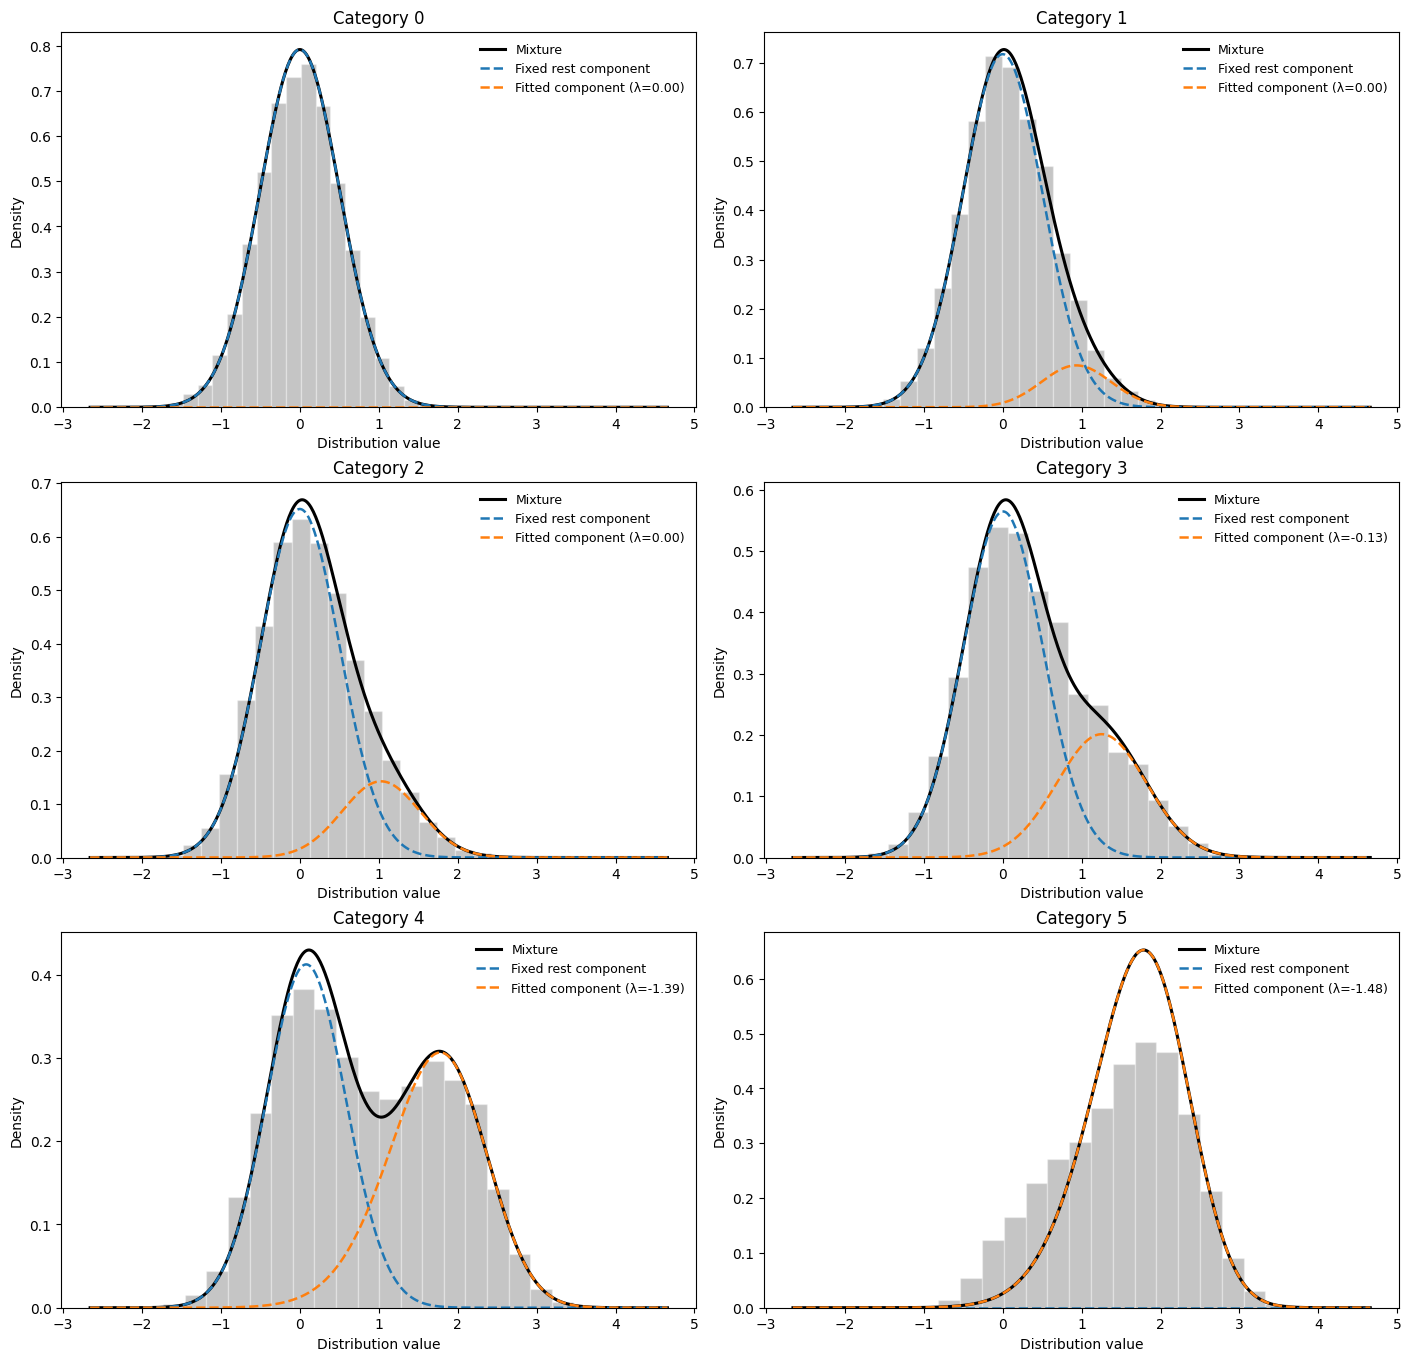

In [29]:
from math import ceil

n_cols = 2
n_rows = ceil(len(categories) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

x_grid = np.linspace(
    min(np.min(measured_distributions[cat]) for cat in categories) - 0.5,
    max(np.max(measured_distributions[cat]) for cat in categories) + 0.5,
    500,
)

for ax, cat in zip(axes, categories):
    x = np.asarray(measured_distributions[cat], dtype=float)
    fit = mixture_fits[cat]
    mu0    = fit['mu0']
    sigma0 = fit['sigma0']
    alpha  = fit['alpha']
    mu1    = fit['mu1']
    sigma1 = fit['sigma1']
    lam    = fit['lambda']

    ax.hist(x, bins=20, density=True, alpha=0.35, color='0.35', edgecolor='white')

    p0   = norm.pdf(x_grid, loc=mu0, scale=sigma0)
    p1   = skewnorm.pdf(x_grid, a=lam, loc=mu1, scale=sigma1)
    pmix = alpha * p0 + (1.0 - alpha) * p1

    ax.plot(x_grid, pmix,                  color='black',       lw=2.2, label='Mixture')
    ax.plot(x_grid, alpha * p0,            color='tab:blue',    lw=1.8, ls='--', label='Fixed rest component')
    ax.plot(x_grid, (1.0 - alpha) * p1,   color='tab:orange',  lw=1.8, ls='--', label=f'Fitted component (λ={lam:.2f})')

    ax.set_title(f'Category {cat}')
    ax.set_xlabel('Distribution value')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=9)

for ax in axes[len(categories):]:
    ax.axis('off')

plt.show()

In [30]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

binary_eval_results = {}
binary_true_all = []
binary_prob_all = []

for cat in categories:
    y_true = np.asarray(binarized_audibilities[cat], dtype=int)
    fit = mixture_fits[cat]
    x = np.asarray(distributions[cat], dtype=float)

    if x.size == 0:
        binary_eval_results[cat] = {
            'n': 0,
            'roc_auc': np.nan,
            'accuracy_0p5': np.nan,
            'balanced_accuracy_0p5': np.nan,
            'log_loss': np.nan,
            'brier_score': np.nan,
            'mean_prob_class1': np.nan,
        }
        continue

    lam = fit['lambda']
    p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
    p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
    p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)
    y_pred = (p_class1 >= 0.5).astype(int)

    binary_eval_results[cat] = {
        'n': int(y_true.size),
        'roc_auc': roc_auc_score(y_true, p_class1) if np.unique(y_true).size > 1 else np.nan,
        'accuracy_0p5': accuracy_score(y_true, y_pred),
        'balanced_accuracy_0p5': balanced_accuracy_score(y_true, y_pred),
        'log_loss': log_loss(y_true, np.clip(p_class1, 1e-6, 1 - 1e-6), labels=[0, 1]),
        'brier_score': brier_score_loss(y_true, p_class1),
        'mean_prob_class1': float(np.mean(p_class1)),
    }
    binary_true_all.append(y_true)
    binary_prob_all.append(p_class1)

if binary_true_all:
    y_true_all = np.concatenate(binary_true_all)
    y_prob_all = np.concatenate(binary_prob_all)
    y_pred_all = (y_prob_all >= 0.5).astype(int)
    print('Aggregate binary evaluation:')
    print(f"  ROC AUC: {roc_auc_score(y_true_all, y_prob_all):.3f}")
    print(f"  Accuracy @ 0.5: {accuracy_score(y_true_all, y_pred_all):.3f}")
    print(f"  Balanced accuracy @ 0.5: {balanced_accuracy_score(y_true_all, y_pred_all):.3f}")
    print(f"  Log loss: {log_loss(y_true_all, np.clip(y_prob_all, 1e-6, 1 - 1e-6), labels=[0, 1]):.3f}")
    print(f"  Brier score: {brier_score_loss(y_true_all, y_prob_all):.3f}")
    print()

for cat in categories:
    res = binary_eval_results[cat]
    print(
        f"Cat {cat}: n={res['n']}, ROC AUC={res['roc_auc']:.3f}, "
        f"Acc@0.5={res['accuracy_0p5']:.3f}, BalAcc@0.5={res['balanced_accuracy_0p5']:.3f}, "
        f"LogLoss={res['log_loss']:.3f}, Brier={res['brier_score']:.3f}, "
        f"mean P(class=1)={res['mean_prob_class1']:.3f}"
    )

Aggregate binary evaluation:
  ROC AUC: 0.880
  Accuracy @ 0.5: 0.809
  Balanced accuracy @ 0.5: 0.797
  Log loss: 0.741
  Brier score: 0.159

Cat 0: n=156, ROC AUC=0.500, Acc@0.5=0.955, BalAcc@0.5=0.500, LogLoss=0.620, Brier=0.045, mean P(class=1)=0.000
Cat 1: n=149, ROC AUC=0.469, Acc@0.5=0.872, BalAcc@0.5=0.555, LogLoss=0.587, Brier=0.112, mean P(class=1)=0.116
Cat 2: n=156, ROC AUC=0.554, Acc@0.5=0.712, BalAcc@0.5=0.551, LogLoss=1.028, Brier=0.234, mean P(class=1)=0.182
Cat 3: n=153, ROC AUC=0.704, Acc@0.5=0.660, BalAcc@0.5=0.659, LogLoss=1.140, Brier=0.279, mean P(class=1)=0.317
Cat 4: n=152, ROC AUC=0.807, Acc@0.5=0.658, BalAcc@0.5=0.745, LogLoss=1.053, Brier=0.280, mean P(class=1)=0.557
Cat 5: n=151, ROC AUC=nan, Acc@0.5=1.000, BalAcc@0.5=1.000, LogLoss=0.000, Brier=0.000, mean P(class=1)=1.000


/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [31]:
print(len(binarized_audibilities[cat]), len(distributions[cat]))

151 151


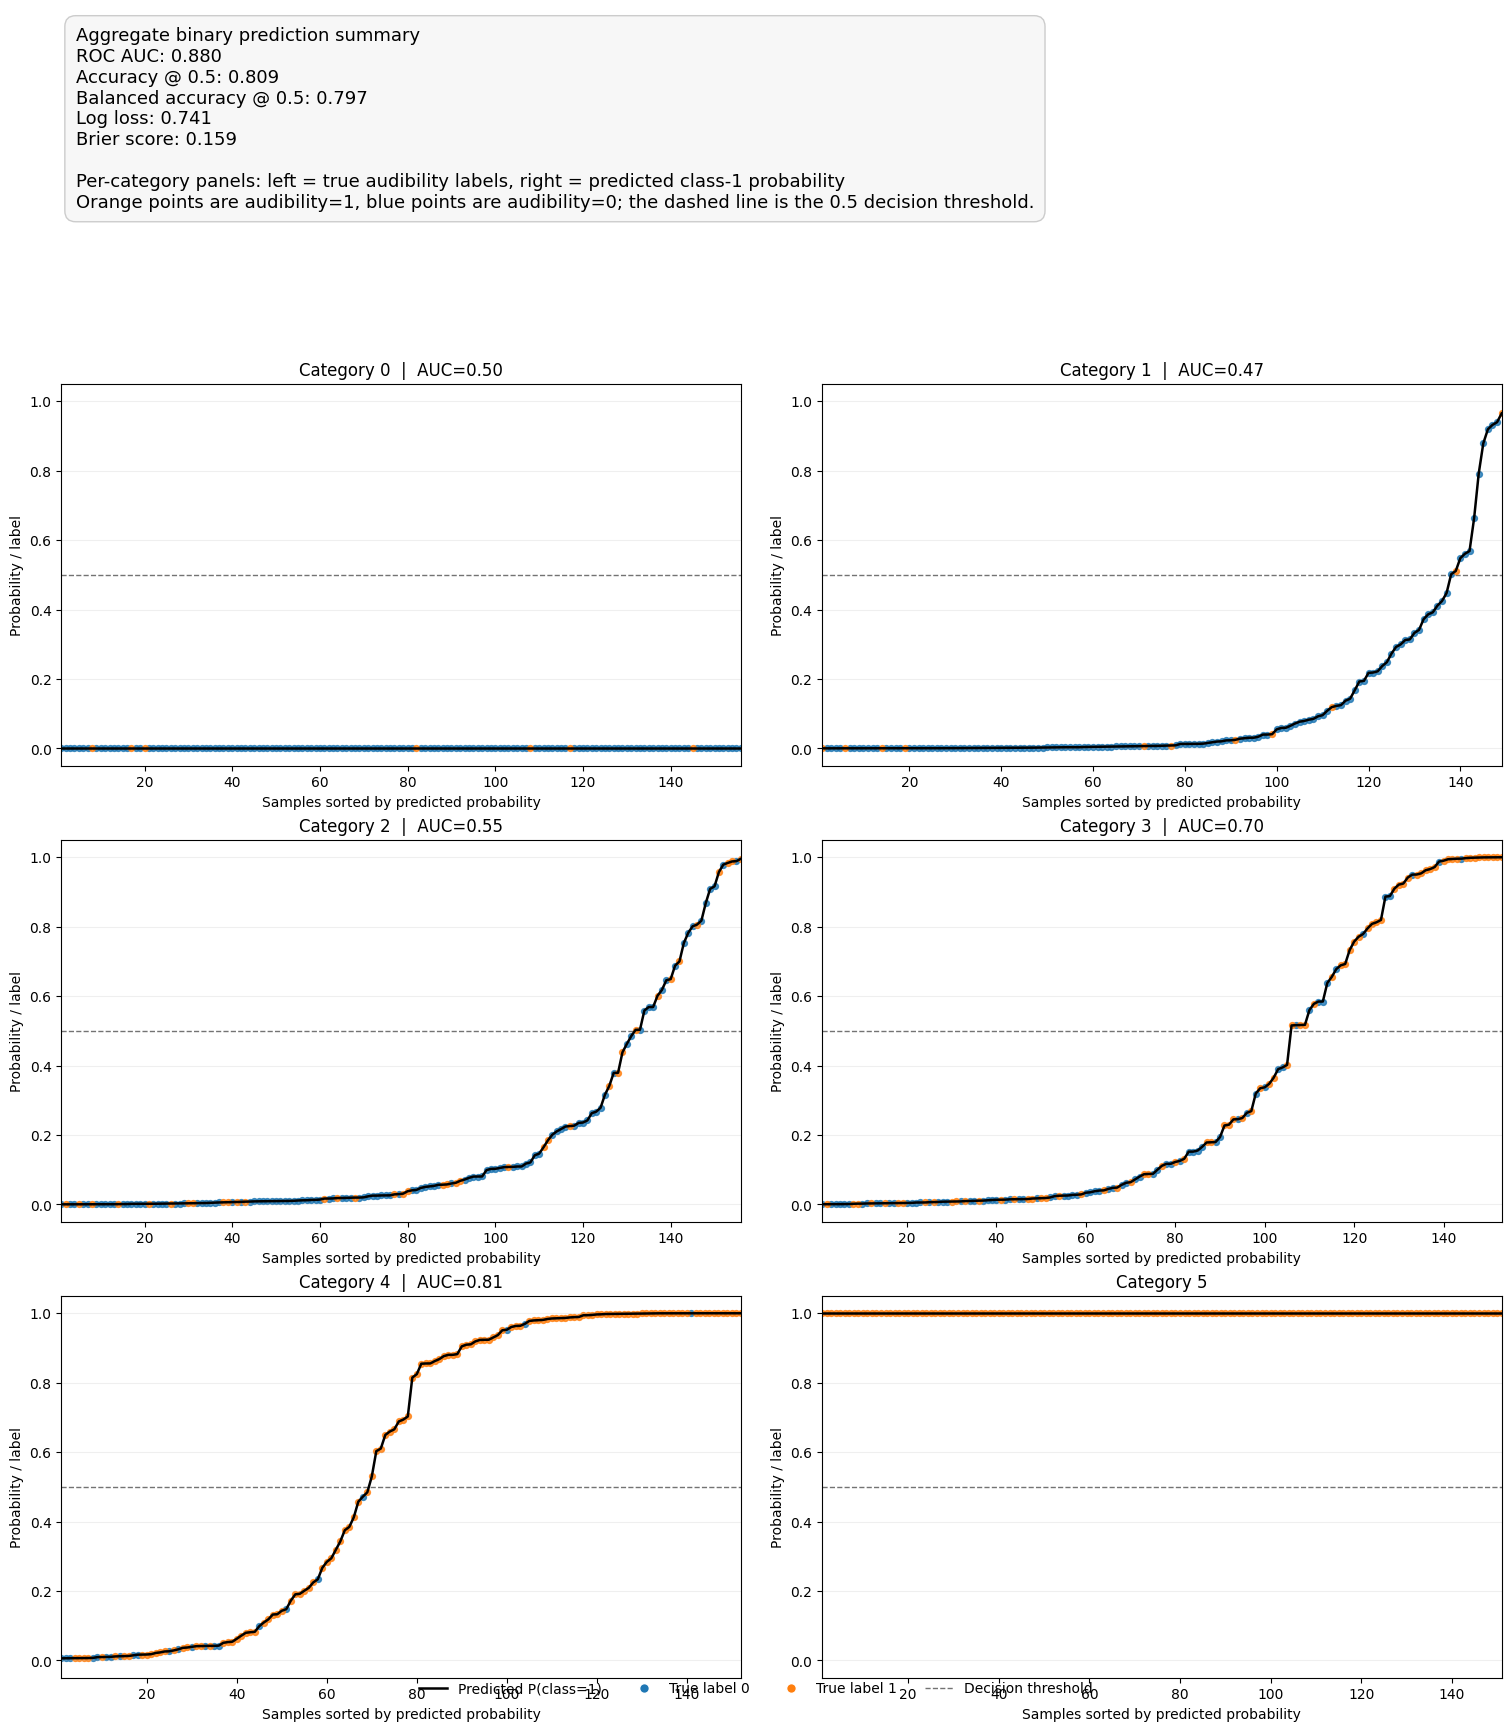

In [32]:
from math import ceil
import matplotlib as mpl
from matplotlib.lines import Line2D

summary_metrics = {
    'ROC AUC': roc_auc_score(y_true_all, y_prob_all) if binary_true_all else np.nan,
    'Accuracy @ 0.5': accuracy_score(y_true_all, y_pred_all) if binary_true_all else np.nan,
    'Balanced accuracy @ 0.5': balanced_accuracy_score(y_true_all, y_pred_all) if binary_true_all else np.nan,
    'Log loss': log_loss(y_true_all, np.clip(y_prob_all, 1e-6, 1 - 1e-6), labels=[0, 1]) if binary_true_all else np.nan,
    'Brier score': brier_score_loss(y_true_all, y_prob_all) if binary_true_all else np.nan,
}

n_cols = 2
n_rows = ceil(len(categories) / n_cols) + 1
fig = plt.figure(figsize=(15, 4.3 * n_rows), constrained_layout=True)
outer = fig.add_gridspec(n_rows, n_cols, height_ratios=[0.9] + [1.0] * (n_rows - 1))

ax_summary = fig.add_subplot(outer[0, :])
ax_summary.axis('off')

summary_text = [
    'Aggregate binary prediction summary',
    *[f'{name}: {value:.3f}' for name, value in summary_metrics.items()],
    '',
    'Per-category panels: left = true audibility labels, right = predicted class-1 probability',
    'Orange points are audibility=1, blue points are audibility=0; the dashed line is the 0.5 decision threshold.'
]
ax_summary.text(
    0.01, 0.95,
    '\n'.join(summary_text),
    va='top', ha='left', fontsize=13, family='sans-serif',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f7f7f7', edgecolor='0.8'),
)

for idx, cat in enumerate(categories):
    row = 1 + idx // n_cols
    col = idx % n_cols
    ax = fig.add_subplot(outer[row, col])

    y_true = np.asarray(binarized_audibilities[cat], dtype=int)
    fit    = binary_eval_results[cat]
    x      = np.asarray(distributions[cat], dtype=float)

    if x.size == 0:
        ax.set_axis_off()
        ax.set_title(f'Category {cat} (no data)')
        continue

    lam    = mixture_fits[cat]['lambda']
    p_rest = mixture_fits[cat]['alpha'] * norm.pdf(x, loc=mixture_fits[cat]['mu0'], scale=mixture_fits[cat]['sigma0'])
    p_alt  = (1.0 - mixture_fits[cat]['alpha']) * skewnorm.pdf(x, a=lam, loc=mixture_fits[cat]['mu1'], scale=mixture_fits[cat]['sigma1'])
    p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)

    order    = np.argsort(p_class1)
    p_sorted = p_class1[order]
    y_sorted = y_true[order]
    sample_idx = np.arange(1, p_sorted.size + 1)

    ax.axhline(0.5, color='0.45', lw=1.0, ls='--', zorder=0)
    ax.plot(sample_idx, p_sorted, color='black', lw=1.8, label='Predicted P(class=1)')
    ax.scatter(sample_idx[y_sorted == 0], p_sorted[y_sorted == 0], s=18, color='tab:blue',   alpha=0.8, label='True label 0')
    ax.scatter(sample_idx[y_sorted == 1], p_sorted[y_sorted == 1], s=18, color='tab:orange', alpha=0.8, label='True label 1')

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(1, max(1, p_sorted.size))
    ax.set_title(
        f'Category {cat}  |  AUC={fit["roc_auc"]:.2f}' if np.isfinite(fit['roc_auc']) else f'Category {cat}'
    )
    ax.set_xlabel('Samples sorted by predicted probability')
    ax.set_ylabel('Probability / label')
    ax.grid(axis='y', alpha=0.2)

for extra_row in range(1 + len(categories) // n_cols, n_rows):
    for extra_col in range(n_cols):
        if extra_row * n_cols + extra_col >= len(categories) + n_cols:
            break

handles = [
    Line2D([0], [0], color='black', lw=1.8, label='Predicted P(class=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',   markersize=7, label='True label 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label='True label 1'),
    Line2D([0], [0], color='0.45', lw=1.0, ls='--', label='Decision threshold'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.01))
plt.show()

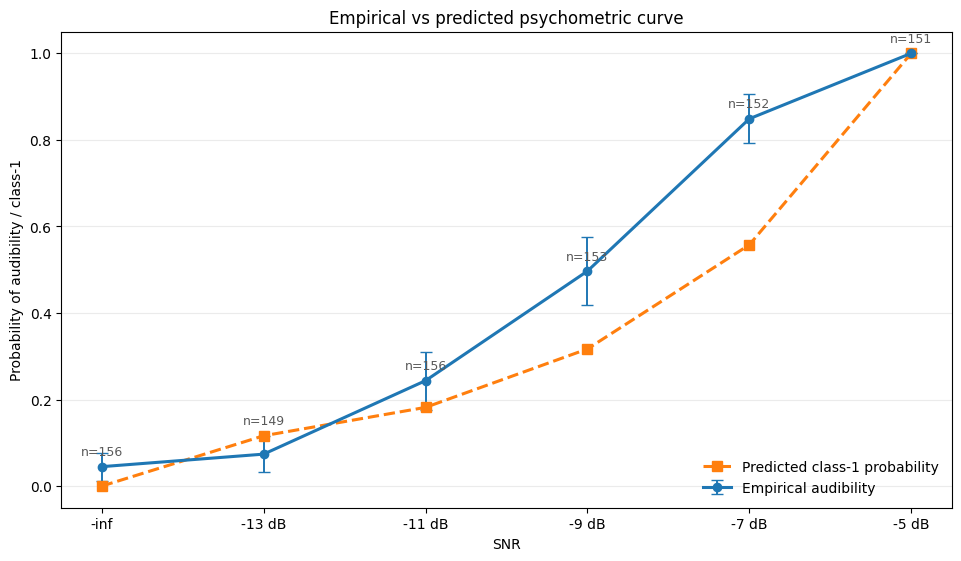

In [33]:
import numpy as np
import matplotlib.pyplot as plt

snr_values = SNRs[:len(categories)]
snr_labels = [('-inf' if not np.isfinite(v) else f'{int(v)} dB') for v in snr_values]
x_pos = np.arange(len(categories))

empirical_mean = []
predicted_mean = []
empirical_ci_low = []
empirical_ci_high = []
n_per_level = []

for cat in categories:
    y_true = np.asarray(binarized_audibilities[cat], dtype=int)
    x = np.asarray(distributions[cat], dtype=float)
    fit = mixture_fits[cat]

    if x.size == 0 or y_true.size == 0:
        empirical_mean.append(np.nan)
        predicted_mean.append(np.nan)
        empirical_ci_low.append(np.nan)
        empirical_ci_high.append(np.nan)
        n_per_level.append(0)
        continue

    lam    = fit['lambda']
    p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
    p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
    p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)

    empirical = float(np.mean(y_true))
    predicted = float(np.mean(p_class1))
    n_obs = int(y_true.size)
    se = np.sqrt(max(empirical * (1.0 - empirical), 0.0) / max(n_obs, 1))
    ci_half_width = 1.96 * se

    empirical_mean.append(empirical)
    predicted_mean.append(predicted)
    empirical_ci_low.append(max(0.0, empirical - ci_half_width))
    empirical_ci_high.append(min(1.0, empirical + ci_half_width))
    n_per_level.append(n_obs)

empirical_mean     = np.asarray(empirical_mean, dtype=float)
predicted_mean     = np.asarray(predicted_mean, dtype=float)
empirical_ci_low   = np.asarray(empirical_ci_low, dtype=float)
empirical_ci_high  = np.asarray(empirical_ci_high, dtype=float)

prior_mean = np.asarray([1.0 - mixture_fits[cat]['alpha'] for cat in categories], dtype=float)

fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)

ax.errorbar(
    x_pos, empirical_mean,
    yerr=[empirical_mean - empirical_ci_low, empirical_ci_high - empirical_mean],
    fmt='o-', color='tab:blue', ecolor='tab:blue',
    elinewidth=1.4, capsize=4, lw=2.2,
    label='Empirical audibility',
)
ax.plot(
    x_pos, predicted_mean,
    's--', color='tab:orange', lw=2.2, ms=7,
    label='Predicted class-1 probability',
)

# ax.plot(x_pos, prior_mean, 'd-.', color='tab:green', lw=2.0, ms=7, label='Prior (1 - alpha)')

for xp, y_emp, y_pred, n_obs in zip(x_pos, empirical_mean, predicted_mean, n_per_level):
    if np.isfinite(y_emp) and np.isfinite(y_pred):
        ax.annotate(
            f'n={n_obs}', (xp, max(y_emp, y_pred)),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=9, color='0.35',
        )

ax.set_title('Empirical vs predicted psychometric curve')
ax.set_xlabel('SNR')
ax.set_xticks(x_pos)
ax.set_xticklabels(snr_labels)
ax.set_ylabel('Probability of audibility / class-1')
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, loc='lower right')

plt.show()